# Caracterizacao inicial da serie

**Objetivo:** entender o comportamento geral da serie antes de avancar para sazonalidade, decomposicao e modelagem.

Nesta etapa vamos responder perguntas como:
- Qual e o nivel tipico de internacoes?
- Qual e a variabilidade diaria da serie?
- Existem picos muito extremos?
- A serie oscila em torno de um padrao de curto prazo?

Para isso, vamos preparar a base temporal, calcular estatisticas descritivas e visualizar a serie bruta junto de medias moveis.

## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
import certifi
import requests

In [ ]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/DataSus/respiratory_hospitalization_time_series.csv"

response = requests.get(url_internacoes, verify=certifi.where(), timeout=60)
response.raise_for_status()

df_internacoes = pd.read_csv(StringIO(response.text))

In [12]:
print("Dimensões:", df_internacoes.shape)

print("\nTipos:")
print(df_internacoes.dtypes)

print("\nAmostra:")
display(df_internacoes.head(10))

print("\nValores ausentes por coluna (top 20):")
na_counts = df_internacoes.isna().sum().sort_values(ascending=False)
na_perc   = (df_internacoes.isna().mean()*100).round(2).sort_values(ascending=False)
display(pd.DataFrame({"NA_count": na_counts, "NA_%": na_perc}).head(20))

Dimensões: (5113, 2)

Tipos:
data_dia           object
num_internacoes     int64
dtype: object

Amostra:


,data_dia,num_internacoes
0,2012-01-01,546
1,2012-01-02,784
2,2012-01-03,462
3,2012-01-04,448
4,2012-01-05,434
5,2012-01-06,560
6,2012-01-07,322
7,2012-01-08,420
8,2012-01-09,476
9,2012-01-10,588



Valores ausentes por coluna (top 20):


,NA_count,NA_%
data_dia,0,0.0
num_internacoes,0,0.0


## Caracterização Inicial

In [13]:
df_serie = df_internacoes.copy()

df_serie["data_dia"] = pd.to_datetime(df_serie["data_dia"], errors="coerce")

df_serie = df_serie.sort_values("data_dia").reset_index(drop=True)

# Calculando a média móvel de 7 e 30 dias para suavizar a série temporal
df_serie["mm_7d"] = df_serie["num_internacoes"].rolling(window=7, min_periods=1).mean()
df_serie["mm_30d"] = df_serie["num_internacoes"].rolling(window=30, min_periods=1).mean()

print("Periodo da serie:", df_serie["data_dia"].min().date(), "até", df_serie["data_dia"].max().date())
print("Numero de observacoes:", len(df_serie))

display(df_serie.head())

Periodo da serie: 2012-01-01 até 2025-12-30
Numero de observacoes: 5113


,data_dia,num_internacoes,mm_7d,mm_30d
0,2012-01-01,546,546.000000,546.000000
1,2012-01-02,784,665.000000,665.000000
2,2012-01-03,462,597.333333,597.333333
3,2012-01-04,448,560.000000,560.000000
4,2012-01-05,434,534.800000,534.800000


### Estatisticas descritivas

Aqui resumimos a serie em medidas simples. A media e a mediana ajudam a entender o nivel central, enquanto desvio padrao, quartis e percentis mostram a dispersao e o peso dos extremos.

Tambem listamos os dias com maior numero de internacoes para ja identificar eventos ou picos que merecem investigacao mais adiante.

In [14]:
# Calculando medidas de posicao e dispersao da serie.
q1 = df_serie["num_internacoes"].quantile(0.25)
q3 = df_serie["num_internacoes"].quantile(0.75)
iqr = q3 - q1
media = df_serie["num_internacoes"].mean()
desvio = df_serie["num_internacoes"].std()

resumo_inicial = pd.DataFrame(
    {
        "metrica": [
            "media",
            "mediana",
            "desvio_padrao",
            "minimo",
            "maximo",
            "q1",
            "q3",
            "iqr",
            "percentil_95",
            "percentil_99",
            "coeficiente_de_variacao"
        ],
        "valor": [
            media,
            df_serie["num_internacoes"].median(),
            desvio,
            df_serie["num_internacoes"].min(),
            df_serie["num_internacoes"].max(),
            q1,
            q3,
            iqr,
            df_serie["num_internacoes"].quantile(0.95),
            df_serie["num_internacoes"].quantile(0.99),
            desvio / media
        ]
    }
)

display(resumo_inicial.round(2))

print("Dias com maiores volumes de internacoes:")
display(
    df_serie.nlargest(10, "num_internacoes")[["data_dia", "num_internacoes"]]
    .reset_index(drop=True)
)


,metrica,valor
0,media,322.84
1,mediana,282.00
2,desvio_padrao,202.26
3,minimo,3.00
4,maximo,1358.00
5,q1,180.00
6,q3,432.00
7,iqr,252.00
8,percentil_95,714.00
9,percentil_99,978.52


Dias com maiores volumes de internacoes:


,data_dia,num_internacoes
0,2012-05-28,1358
1,2012-05-23,1316
2,2012-05-22,1302
3,2012-05-14,1288
4,2012-05-18,1260
5,2012-05-30,1260
6,2012-06-25,1218
7,2012-05-17,1204
8,2012-05-25,1204
9,2015-05-19,1199


### Visualizacao temporal da serie

O grafico abaixo mostra a serie diaria original e duas medias moveis:
- `mm_7d`: suaviza o ruido diario e destaca o comportamento semanal.
- `mm_30d`: mostra melhor o nivel de medio prazo da serie.

Se a linha diaria estiver muito espalhada, isso indica alta volatilidade. Se as medias moveis mudarem bastante ao longo do tempo, ja temos sinal de tendencia ou mudanca de regime.

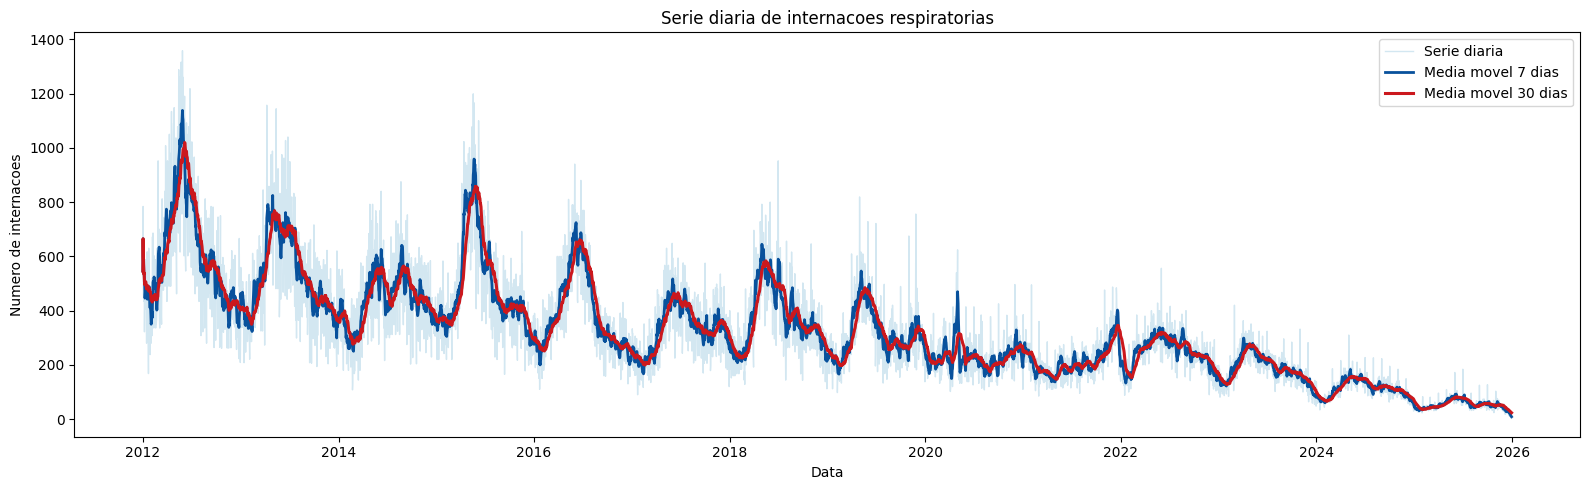

In [15]:
plt.figure(figsize=(16, 5))

plt.plot(
    df_serie["data_dia"],
    df_serie["num_internacoes"],
    color="#9ecae1",
    linewidth=1,
    alpha=0.45,
    label="Serie diaria"
)

plt.plot(
    df_serie["data_dia"],
    df_serie["mm_7d"],
    color="#08519c",
    linewidth=2,
    label="Media movel 7 dias"
)

plt.plot(
    df_serie["data_dia"],
    df_serie["mm_30d"],
    color="#cb181d",
    linewidth=2.2,
    label="Media movel 30 dias"
)

plt.title("Serie diaria de internacoes respiratorias")
plt.xlabel("Data")
plt.ylabel("Numero de internacoes")
plt.legend()
plt.tight_layout()
plt.show()

### Distribuicao dos valores

A serie temporal pode ter comportamento muito assimetrico. Por isso, alem do grafico no tempo, vale olhar a distribuicao dos valores diarios.

O histograma mostra onde a maior parte dos dias se concentra. O boxplot ajuda a ver a dispersao, a mediana e a presenca de valores extremos.

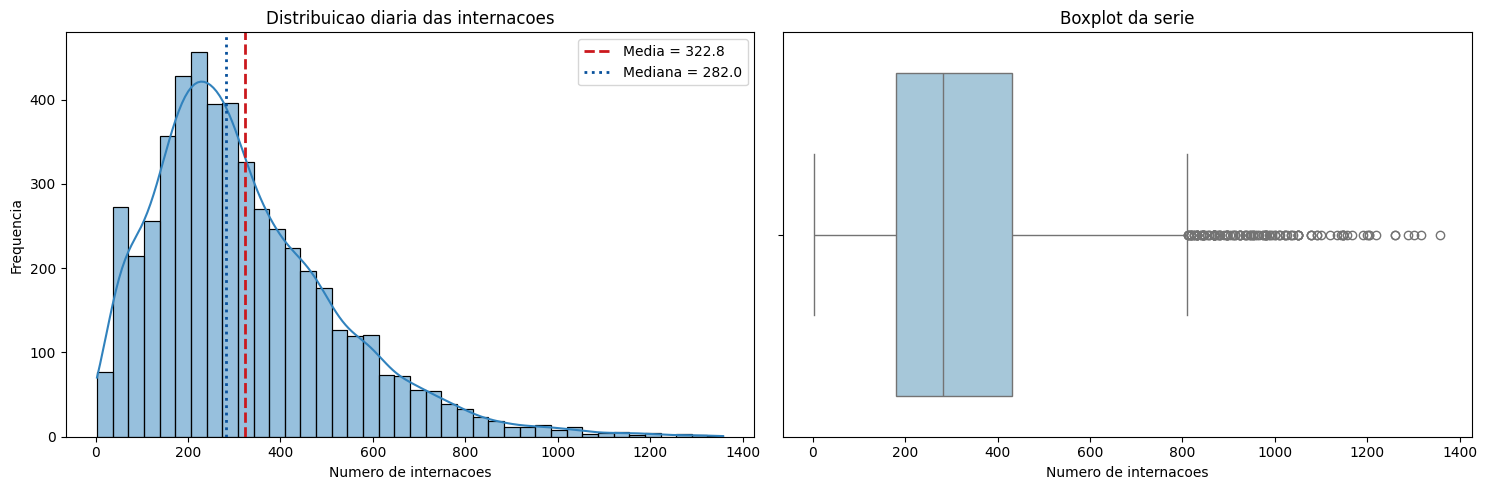

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_serie["num_internacoes"], bins=40, kde=True, color="#3182bd", ax=axes[0])
axes[0].axvline(
    df_serie["num_internacoes"].mean(),
    color="#cb181d",
    linestyle="--",
    linewidth=2,
    label=f"Media = {df_serie['num_internacoes'].mean():.1f}"
)
axes[0].axvline(
    df_serie["num_internacoes"].median(),
    color="#08519c",
    linestyle=":",
    linewidth=2,
    label=f"Mediana = {df_serie['num_internacoes'].median():.1f}"
)
axes[0].set_title("Distribuicao diaria das internacoes")
axes[0].set_xlabel("Numero de internacoes")
axes[0].set_ylabel("Frequencia")
axes[0].legend()

sns.boxplot(x=df_serie["num_internacoes"], color="#9ecae1", ax=axes[1])
axes[1].set_title("Boxplot da serie")
axes[1].set_xlabel("Numero de internacoes")

plt.tight_layout()
plt.show()

### Resumo interpretativo dos resultados

A serie atualizada apresenta uma media de aproximadamente **322,8 internacoes por dia**, mas a **mediana de 282** mostra que os dias mais tipicos ainda ficam abaixo da media. Essa diferenca entre media e mediana sugere **assimetria a direita**, isto e, alguns dias muito altos estao puxando a media para cima.

A variabilidade tambem e bastante elevada. O **desvio padrao foi 202,3**, o **IQR foi 252** e o **coeficiente de variacao ficou em 0,63**, indicando que a oscilacao diaria e grande em relacao ao proprio nivel da serie. Os percentis reforcam esse diagnostico: **95% dos dias ficaram abaixo de 714 internacoes** e **99% abaixo de 978,5**, enquanto o valor maximo chegou a **1358**. Portanto, a serie nao se comporta como uma sequencia de pequenas flutuacoes em torno de um nivel fixo, ela contem **picos extremos muito relevantes**.

Os maiores volumes ficaram fortemente concentrados em **maio e junho de 2012**, com varios dias acima de **1200 internacoes**, e apareceu ainda um pico importante em **maio de 2015**. Isso sugere que os eventos extremos nao estao distribuidos uniformemente no tempo, mas sim concentrados em **janelas muito especificas**, o que pode refletir ondas respiratorias mais intensas, mudancas de regime ou ate alteracoes de registro que precisam ser verificadas adiante.

**Possiveis analises e consequencias**
- A diferenca entre media e mediana, junto da cauda a direita observada na distribuicao, sugere testar transformacoes como `log1p` ou `Box-Cox` antes da modelagem.
- A presenca de picos muito altos no boxplot e nos maiores valores diarios indica que vale investigar **outliers**, **ondas epidemiologicas** e possiveis **quebras de registro**.
- Como os maiores picos ficaram concentrados em **maio-junho de 2012**, a proxima secao de sazonalidade deve verificar se esse comportamento acompanha um padrao recorrente de calendario ou se parece mais um evento excepcional.
- Para modelagem futura, essa configuracao ja antecipa a necessidade de abordagens robustas a extremos e possivelmente de variaveis indicadoras para periodos anormais.
